In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

data = fetch_california_housing()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)
y_pred = lin_reg.predict(X_test_scaled)

print("Linear Regression Results:")
print("MSE:", mean_squared_error(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))

Linear Regression Results:
MSE: 0.5558915986952442
MAE: 0.5332001304956566
R²: 0.575787706032451


24EU02039 - First Five Rows of Dataset

      crim    zn  indus  chas    nox     rm   age     dis  rad  tax  ptratio  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        b  lstat  medv  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  

24EU02039 - Dataset Shape: (506, 14)

24EU02039 - Support Vector Regression
Mean Absolute Error (MAE): 2.7317
Mean Squared Error (MSE): 25.6685
Root Mean Squared Error (RMSE): 5.0664
R2 Score: 0.65

24EU02039 - Decision Tree Regression
Mean Absolute Error (MAE): 2.3941
Mean Squared Error (MSE): 10.4161
Root Mean Squared Error 

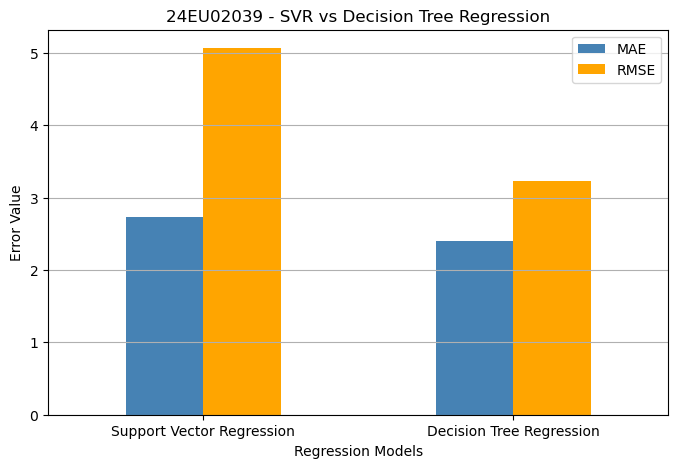

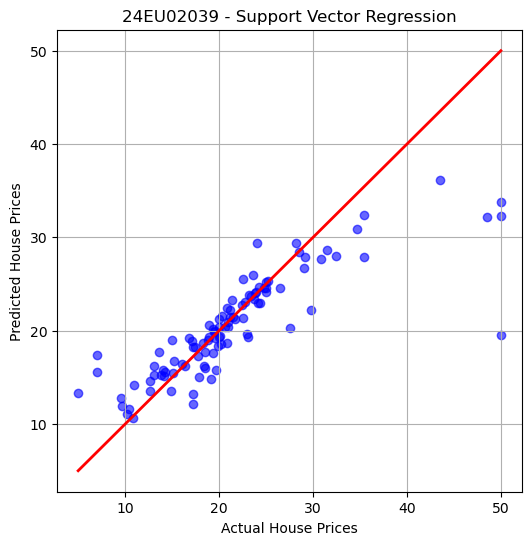

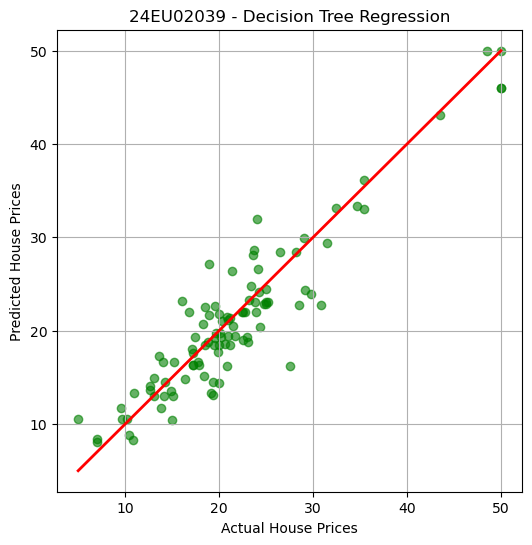

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"
df = pd.read_csv(url)

print("24EU02039 - First Five Rows of Dataset\n")
print(df.head())

print("\n24EU02039 - Dataset Shape:", df.shape)

# Features and Target
X = df.drop("medv", axis=1)
y = df["medv"]


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

#
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


svr = SVR(kernel='rbf')

svr.fit(X_train_scaled, y_train)

y_pred_svr = svr.predict(X_test_scaled)


dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)


def evaluate_model(model_name, y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    print("\n" + "="*50)
    print("24EU02039 -", model_name)
    print("="*50)
    print("Mean Absolute Error (MAE):", round(mae, 4))
    print("Mean Squared Error (MSE):", round(mse, 4))
    print("Root Mean Squared Error (RMSE):", round(rmse, 4))
    print("R2 Score:", round(r2, 4))

    return [model_name, mae, mse, rmse, r2]


results = []

results.append(evaluate_model("Support Vector Regression", y_test, y_pred_svr))
results.append(evaluate_model("Decision Tree Regression", y_test, y_pred_dt))


comparison = pd.DataFrame(
    results,
    columns=["Model", "MAE", "MSE", "RMSE", "R2 Score"]
)

print("\n24EU02039 - Model Comparison\n")
print(comparison)


comparison.set_index("Model")[["MAE", "RMSE"]].plot(
    kind="bar",
    figsize=(8,5),
    color=["steelblue", "orange"]
)

plt.title("24EU02039 - SVR vs Decision Tree Regression")
plt.xlabel("Regression Models")
plt.ylabel("Error Value")
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()


plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred_svr, color="blue", alpha=0.6)

plt.plot(
    [min(y_test), max(y_test)],
    [min(y_test), max(y_test)],
    color="red",
    linewidth=2
)

plt.title("24EU02039 - Support Vector Regression")
plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.grid(True)

plt.show()


plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred_dt, color="green", alpha=0.6)

plt.plot(
    [min(y_test), max(y_test)],
    [min(y_test), max(y_test)],
    color="red",
    linewidth=2
)

plt.title("24EU02039 - Decision Tree Regression")
plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.grid(True)

plt.show()


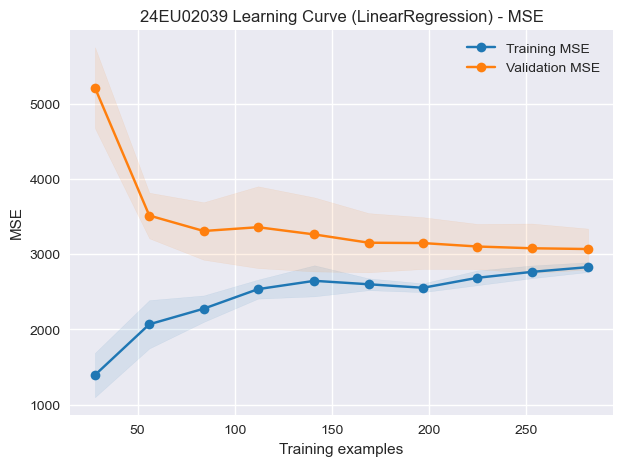

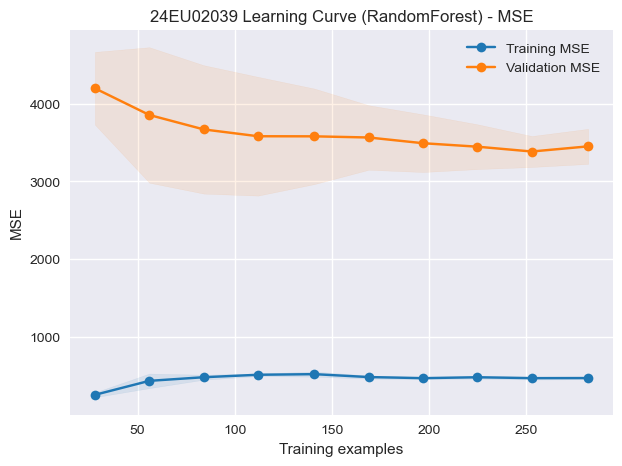

=== 24EU02039 LinearRegression ===
Train MSE : 2868.550
Test  MSE : 2900.194
Train RMSE: 53.559
Test  RMSE: 53.853
Train MAE : 43.484
Test  MAE : 42.794
Train R^2 : 0.528
Test  R^2 : 0.453

=== 24EU02039 RandomForest ===
Train MSE : 457.749
Test  MSE : 2966.024
Train RMSE: 21.395
Test  RMSE: 54.461
Train MAE : 17.433
Test  MAE : 44.276
Train R^2 : 0.925
Test  R^2 : 0.440

=== 24EU02039 Cross-validated (LinearRegression) ===
MSE  mean: 2993.081  std: 150.771
RMSE mean: 54.692  std: 1.375
R^2  mean: 0.482  std: 0.049

=== 24EU02039 Cross-validated (RandomForest) ===
MSE  mean: 3353.955  std: 272.697
RMSE mean: 57.865  std: 2.355
R^2  mean: 0.421  std: 0.054



In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, learning_curve, KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

plt.style.use("seaborn-v0_8")
%matplotlib inline

data = load_diabetes()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(
        n_estimators=200,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    )
}

def plot_learning_curve_for_model(model, model_name, X, y, scoring="neg_mean_squared_error"):
    train_sizes, train_scores, valid_scores = learning_curve(
        estimator=model,
        X=X,
        y=y,
        cv=KFold(n_splits=5, shuffle=True, random_state=42),
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring=scoring,
        n_jobs=-1
    )
    train_mse = -train_scores
    valid_mse = -valid_scores
    train_mean = np.mean(train_mse, axis=1)
    train_std = np.std(train_mse, axis=1)
    valid_mean = np.mean(valid_mse, axis=1)
    valid_std = np.std(valid_mse, axis=1)
    plt.figure(figsize=(7, 5))
    plt.title(f"24EU02039 Learning Curve ({model_name}) - MSE")
    plt.xlabel("Training examples")
    plt.ylabel("MSE")
    plt.plot(train_sizes, train_mean, "o-", color="tab:blue", label="Training MSE")
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="tab:blue")
    plt.plot(train_sizes, valid_mean, "o-", color="tab:orange", label="Validation MSE")
    plt.fill_between(train_sizes, valid_mean - valid_std, valid_mean + valid_std, alpha=0.1, color="tab:orange")
    plt.legend(loc="best")
    plt.grid(True)
    plt.show()

def evaluate_regression_model(model, model_name, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    train_rmse = np.sqrt(train_mse)
    test_rmse = np.sqrt(test_mse)
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    print(f"=== 24EU02039 {model_name} ===")
    print(f"Train MSE : {train_mse:.3f}")
    print(f"Test  MSE : {test_mse:.3f}")
    print(f"Train RMSE: {train_rmse:.3f}")
    print(f"Test  RMSE: {test_rmse:.3f}")
    print(f"Train MAE : {train_mae:.3f}")
    print(f"Test  MAE : {test_mae:.3f}")
    print(f"Train R^2 : {train_r2:.3f}")
    print(f"Test  R^2 : {test_r2:.3f}")
    print()

def cross_validated_metrics(model, model_name, X, y):
    neg_mse_scores = cross_val_score(model, X, y, cv=5, scoring="neg_mean_squared_error", n_jobs=-1)
    mse_scores = -neg_mse_scores
    rmse_scores = np.sqrt(mse_scores)
    r2_scores = cross_val_score(model, X, y, cv=5, scoring="r2", n_jobs=-1)
    print(f"=== 24EU02039 Cross-validated ({model_name}) ===")
    print(f"MSE  mean: {mse_scores.mean():.3f}  std: {mse_scores.std():.3f}")
    print(f"RMSE mean: {rmse_scores.mean():.3f}  std: {rmse_scores.std():.3f}")
    print(f"R^2  mean: {r2_scores.mean():.3f}  std: {r2_scores.std():.3f}")
    print()

for name, model in models.items():
    plot_learning_curve_for_model(model, name, X_train, y_train)

for name, model in models.items():
    evaluate_regression_model(model, name, X_train, y_train, X_test, y_test)

for name, model in models.items():
    cross_validated_metrics(model, name, X, y)